# 02 - EDA, Cleaning and the Cascading Market-Sizing Filter

CRED Market Entry and Segmentation Diagnostic - Shashank Tiwari, IIT Kharagpur

In [1]:
import sys, warnings, logging
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import config
from src.utils import setup_logging
setup_logging(logging.INFO)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
FIG = config.FIGURES_DIR

In [2]:
from src.data_generator import load_raw
from src.preprocessing import clean_data, cascading_filter, engineer_features
cards, panel = load_raw()
clean, report = clean_data(cards)
report

04:50:57 | INFO    | cred.preprocessing | Cleaning: 200,000 -> 195,000 rows | purity = 97.50% (target >= 92%)


04:50:57 | INFO    | cred.preprocessing |   dropped: score=2000 income=1500 nulls=1500 | imputed: age, gender, city, annual_income_lakhs, card_type, card_issuer, months_active, upi_credit_usage, reward_redemption_rate, digital_transaction_pct


{'total_rows': 200000,
 'dropped_invalid_credit_score': 2000,
 'dropped_invalid_income': 1500,
 'dropped_excess_nulls': 1500,
 'imputed_columns': ['age',
  'gender',
  'city',
  'annual_income_lakhs',
  'card_type',
  'card_issuer',
  'months_active',
  'upi_credit_usage',
  'reward_redemption_rate',
  'digital_transaction_pct'],
 'valid_rows': 195000,
 'purity': 0.975}

## Data purity
`purity = valid_rows / total_rows` must be >= 92%. Rows with out-of-range bureau scores, implausible incomes or more than three nulls are dropped; the remaining sparse nulls are median/mode imputed.

## Cascading filter: 119M cards -> 38M holders
1. Geography (top-50 cities)  2. Bureau score >= 600  3. Spend >= INR 2,000  4. Repayment >= 15%

In [3]:
holders, filter_log = cascading_filter(clean)
filter_log

04:51:29 | INFO    | cred.preprocessing |   0. Raw (clean)                   holders= 63,616  removed=  0.0%  cumulative=  0.0%


04:51:29 | INFO    | cred.preprocessing |   1. Geography (top-50 cities)     holders= 58,647  removed=  7.8%  cumulative=  7.8%


04:51:29 | INFO    | cred.preprocessing |   2. Bureau score >= 600           holders= 54,992  removed=  6.2%  cumulative= 13.6%


04:51:29 | INFO    | cred.preprocessing |   3. Spend >= INR 2,000            holders= 47,619  removed= 13.4%  cumulative= 25.1%


04:51:29 | INFO    | cred.preprocessing |   4. Repayment >= 0.150            holders= 47,236  removed=  0.8%  cumulative= 25.8%


04:51:29 | INFO    | cred.preprocessing | Dedup complete: 195,000 cards -> 47,236 holders (represents 119M -> 38M)


,stage,cards,holders,removed_pct,cumulative_removed_pct,holders_scaled_to_market_M
0,0. Raw (clean),195000.0,63616,0.00,0.00,51.18
1,1. Geography (top-50 cities),179710.0,58647,7.81,7.81,47.18
2,2. Bureau score >= 600,NaN,54992,6.23,13.56,44.24
3,"3. Spend >= INR 2,000",NaN,47619,13.41,25.15,38.31
4,4. Repayment >= 0.150,NaN,47236,0.80,25.75,38.00


Text(0, 0.5, 'M holders')

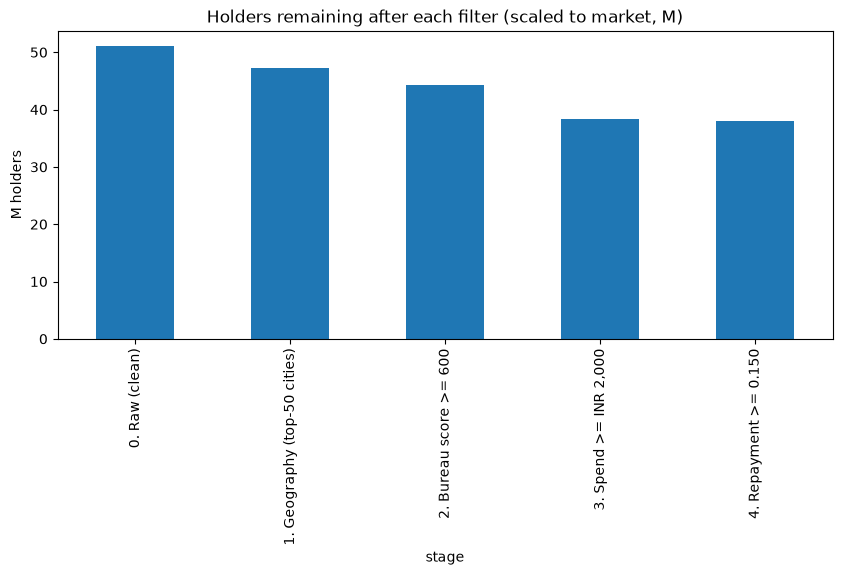

In [4]:
ax = filter_log.set_index('stage')['holders_scaled_to_market_M'].plot.bar(figsize=(10,4), title='Holders remaining after each filter (scaled to market, M)')
ax.set_ylabel('M holders')

## Feature engineering (12 holder-level features)

In [5]:
features = engineer_features(holders, panel)
features[config.ENGINEERED_FEATURES].describe().T

04:51:43 | INFO    | cred.preprocessing | Engineered 12 features for 47,236 holders


,count,mean,std,min,25%,50%,75%,max
total_card_limit,47236.0,13.987941,15.652663,0.100000,4.076209,8.442148,18.122038,187.066677
utilization_ratio,47236.0,0.031954,0.012850,0.001776,0.023304,0.030464,0.040969,0.072395
repayment_discipline,47236.0,0.712175,0.211278,0.124136,0.632490,0.757143,0.862047,1.000000
digital_savviness,47236.0,0.687395,0.176758,0.178569,0.527772,0.713761,0.817414,1.000000
card_diversity,47236.0,2.462677,1.198983,1.000000,1.000000,2.000000,3.000000,6.000000
premium_card_flag,47236.0,0.329219,0.469935,0.000000,0.000000,0.000000,1.000000,1.000000
emi_propensity,47236.0,0.230523,0.421172,0.000000,0.000000,0.000000,0.000000,1.000000
spend_volatility,47236.0,0.262971,0.077370,0.129603,0.205757,0.237629,0.302535,0.957976
income_to_limit_ratio,47236.0,3.391656,3.186918,0.100000,1.279596,2.323107,4.438923,33.246909
missed_payment_flag,47236.0,0.185685,0.388856,0.000000,0.000000,0.000000,0.000000,1.000000


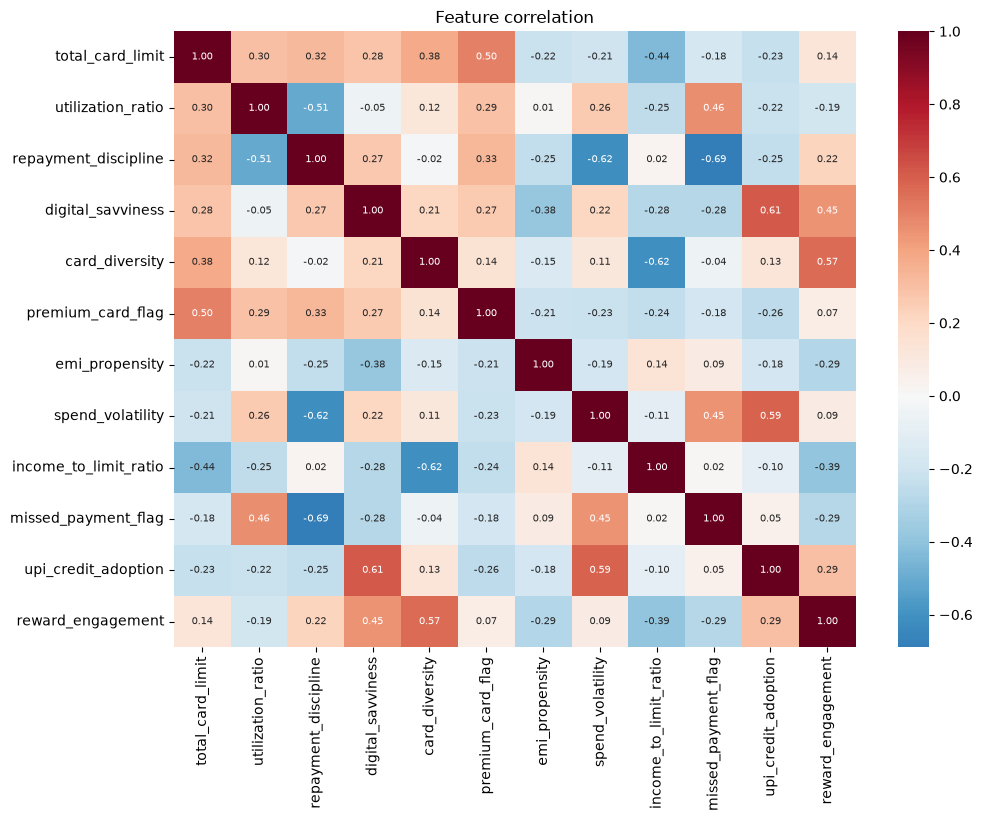

In [6]:
import seaborn as sns
plt.figure(figsize=(11, 8))
sns.heatmap(features[config.ENGINEERED_FEATURES].corr(), cmap='RdBu_r', center=0, annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('Feature correlation');